# Spam SMS Detection
**CodSoft Machine Learning Internship**

---

### ⚖️ Handling Imbalanced Data
Spam datasets are typically highly imbalanced (many more "Ham" messages than "Spam"). If left unaddressed, models can achieve high accuracy simply by predicting "Ham" all the time, but they fail to actually detect spam.

To resolve this, we used **SMOTE (Synthetic Minority Over-sampling Technique)** to artificially generate new examples of the Spam so that the model learns from a perfectly balanced dataset.

### 📂 Dataset
`spam.csv` (contains 'v1' for label and 'v2' for the message)

## 📦 Step 1: Imports

In [ ]:
import os, re, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

# Simple plot style
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False
})
print('✅ Imports successful')

✅ Imports successful


## 📂 Step 2: Load & Clean Data

In [ ]:
project_root = Path.cwd().resolve()
spam_candidates = [
    project_root / 'spam.csv',
    project_root.parent / 'spam.csv',
    project_root / '..' / 'spam.csv',
]
SPAM_CSV = next((p for p in spam_candidates if p.exists()), spam_candidates[0])

# Load data
df = pd.read_csv(SPAM_CSV, encoding='latin-1')[['v1', 'v2']].copy()
df.columns = ['label', 'message']
df.dropna(inplace=True)
df['label'] = df['label'].str.lower().str.strip()

# Simple text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_message'] = df['message'].apply(clean_text)

print(f'✅ Loaded & Cleaned {len(df):,} rows')
df.head(3)

✅ Loaded & Cleaned 5,572 rows


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...


## Exploratory Data Analysis


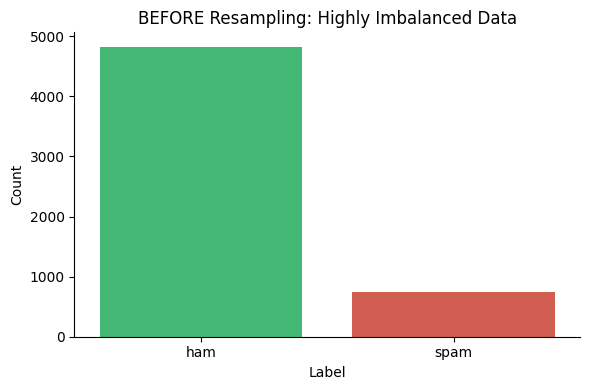

Initial Ham:  4825
Initial Spam: 747 (Only 13.4%)


In [18]:
# ── Show initial Imbalance ──
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', order=['ham', 'spam'], palette=['#2ecc71', '#e74c3c'])
plt.title('BEFORE Resampling: Highly Imbalanced Data')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

counts = df['label'].value_counts()
print(f"Initial Ham:  {counts['ham']}")
print(f"Initial Spam: {counts['spam']} (Only {counts['spam']/len(df)*100:.1f}%)")

## We can see the data is highly imbalanced .

##  Text Vectorization (TF-IDF)

In [19]:
X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert Text to Numbers
tfidf = TfidfVectorizer(max_features=20000, stop_words='english', ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Training data shape: {X_train_tfidf.shape}")

TF-IDF Training data shape: (4457, 20000)


## Applying SMOTE to Balance the Training Data

Before SMOTE:
 label
ham     3859
spam     598
Name: count, dtype: int64 

After SMOTE:
 label
ham     3859
spam    3859
Name: count, dtype: int64


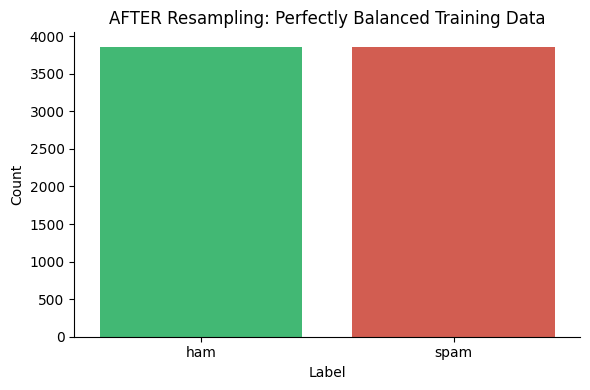

In [20]:
smote = SMOTE(random_state=42)

# Apply SMOTE only on the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

print("Before SMOTE:\n", y_train.value_counts(), "\n")
print("After SMOTE:\n", y_train_resampled.value_counts())

# Visualize the balanced training dataset after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled, order=['ham', 'spam'], palette=['#2ecc71', '#e74c3c'])
plt.title('AFTER Resampling: Perfectly Balanced Training Data')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 🤖 Step 6: Model Training (SVM)

In [21]:
# Train SVM on the perfectly balanced (resampled) training data
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)

print("Training SVM model...")
svm_model.fit(X_train_resampled, y_train_resampled)
print("✅ Training complete!")

Training SVM model...
✅ Training complete!


## Confusion Matrix

⭐ Accuracy: 98.74%

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



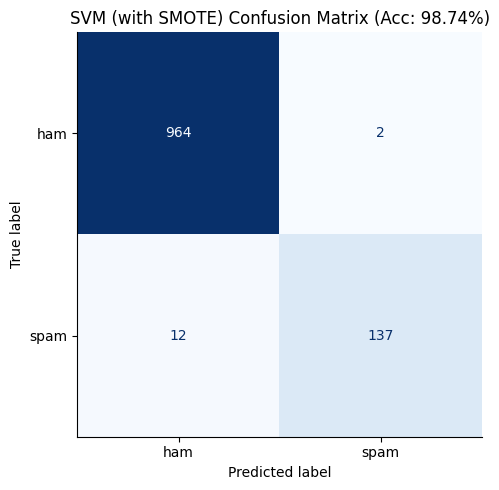

In [24]:
# Predict using the test data (which was NOT touched by SMOTE)
y_pred = svm_model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
print(f"⭐ Accuracy: {acc*100:.2f}%\n")

print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    cmap='Blues', 
    labels=['ham', 'spam'],
    ax=ax,
    colorbar=False
)
ax.set_title(f'SVM (with SMOTE) Confusion Matrix (Acc: {acc*100:.2f}%)')
plt.tight_layout()
plt.show()

## Manual Testing total 50 messages (25 spams + 25 hams).

In [ ]:

custom_test_cases = [
    # --- 25 SPAM MESSAGES ---
    ("CONGRATULATIONS! You've won a $1000 Walmart Gift Card. Click here to claim now!", "spam"),
    ("URGENT: Your bank account has been locked. Verify details immediately at bit.ly/fake-bank", "spam"),
    ("Free entry in a weekly competition to win sports tickets. Text WIN to 87121.", "spam"),
    ("You have been selected for a high paying work-from-home job! Earn $500/day. WhatsApp +123456789.", "spam"),
    ("Claim your free 500 TRX crypto bonus instantly! Visit cryptofree-reward.com", "spam"),
    ("Exclusive Offer: Get 80% off on all luxury watches today only! Shop at fastdeals.net", "spam"),
    ("Your loan of $50,000 has been pre-approved with 0% interest. Reply YES to apply.", "spam"),
    ("Final notice regarding your unpaid tax invoice. Click to resolve immediately or face penalty.", "spam"),
    ("Hot single matches in your area are waiting to chat! Click here to view profiles.", "spam"),
    ("You have 1 unread voice message from an unknown caller. Listen at sound-msg.com/play", "spam"),
    ("Dear customer, your parcel is on hold due to missing address. Update here: post-track-info.com", "spam"),
    ("Get instant credit up to 100,000 rupees without paperwork! Download app now.", "spam"),
    ("Spin the wheel and win a brand new iPhone 15 Pro Max! Only 2 spins left.", "spam"),
    ("Congratulations! Your phone number won $500,000 in the International Mobile Lottery.", "spam"),
    ("Low stock alert! Herbal slimming pills guaranteed to lose 10kg in 1 week. Order now.", "spam"),
    ("Your Netflix subscription has expired. Renew today to avoid interruption: netflix-pay-update.com", "spam"),
    ("Earn passive income fast! Double your Bitcoin in 24 hours guaranteed.", "spam"),
    ("Urgent! Call 09061743811 from a landline to claim your £1500 cash prize.", "spam"),
    ("Special gift for our VIP user: Claim 50 free spins at Casino Deluxe!", "spam"),
    ("Your Apple ID was signed in from a new device. Click here if this wasn't you.", "spam"),
    ("ALERT: Unauthorised transaction of $499 detected on your card. Click to cancel.", "spam"),
    ("Limited time offer: Get 1000 Instagram followers for just $5. Fast delivery!", "spam"),
    ("Congratulations! You have been awarded 500 bonus loyalty points. Redeem at store-gift.com", "spam"),
    ("Need fast cash? Bad credit OK! Get approved in 5 minutes.", "spam"),
    ("You have won a free holiday trip to Bali! Reply WIN to claim your ticket.", "spam"),

    # --- 25 HAM MESSAGES ---
    ("Hey, are we still meeting at the library for the project assignment?", "ham"),
    ("The lab practical scheduled for tomorrow morning has been postponed to 2 PM.", "ham"),
    ("Can you share the Python code for the model implementation when you're done?", "ham"),
    ("Mom asked if you'll be home for dinner tonight or eating out.", "ham"),
    ("Don't forget to submit the project proposal report before midnight.", "ham"),
    ("Your OTP for login to Student Portal is 482910. Valid for 10 minutes. Do not share it.", "ham"),
    ("Hey bro, down for a quick gaming match tonight around 9?", "ham"),
    ("The lecture notes for chapter 4 have been uploaded to the shared folder.", "ham"),
    ("Please review the updated block diagram for our research paper draft.", "ham"),
    ("Are you free for a brief call to discuss the hackathon presentation slides?", "ham"),
    ("Hey, did you get the email regarding the attendance correction for the lab session?", "ham"),
    ("I bought the items we needed from the grocery store, see you at home.", "ham"),
    ("Let's meet near the canteen after the 3rd period lecture.", "ham"),
    ("Can you send me the PDF link for the machine learning textbook?", "ham"),
    ("Your order #84920 has been shipped and is expected to arrive by Thursday.", "ham"),
    ("Hey, just checking in to see if you reached home safely.", "ham"),
    ("Remember to charge your laptop before the engineering workshop tomorrow.", "ham"),
    ("The faculty advisor requested a soft copy of our team project report.", "ham"),
    ("I'll be a bit late for the group study session, start without me.", "ham"),
    ("Thanks for sending over the notes, really appreciate the help!", "ham"),
    ("Is the library open on Saturday for self-study hours?", "ham"),
    ("Your monthly phone bill statement is ready to view in the official app.", "ham"),
    ("Hey, what time does the morning lab session start on Monday?", "ham"),
    ("Let's review the SQL queries once more before the lab test tomorrow.", "ham"),
    ("Hope you have a great weekend! Talk to you on Monday.", "ham")
]

# Update the function to accept the actual label and compare it
def predict_spam_with_comparison(message, actual_label):
    # Clean and Vectorize new message (using your existing variables)
    clean_msg = clean_text(message)
    msg_tfidf = tfidf.transform([clean_msg])
    
    # Predict
    pred = svm_model.predict(msg_tfidf)[0]
    icon = '🚨' if pred == 'spam' else '✅'
    
    # Comparison Logic
    if pred == actual_label:
        comparison_result = f"🟢 MATCH (Model got it right!)"
    else:
        comparison_result = f"❌ MISMATCH (Actually {actual_label.upper()}, but showed {pred.upper()})"
    
    print(f'\n✉️ Message: {message[:100]}...')
    print(f'🎯 Prediction: {pred.upper()} {icon} | {comparison_result}')

# Loop through all 50 test cases and evaluate them
print("Starting evaluation of 50 custom inputs...\n")
for text, true_label in custom_test_cases:
    predict_spam_with_comparison(text, true_label)

Starting evaluation of 50 custom inputs...


✉️ Message: CONGRATULATIONS! You've won a $1000 Walmart Gift Card. Click here to claim now!...
🎯 Prediction: SPAM 🚨 | 🟢 MATCH (Model got it right!)

✉️ Message: URGENT: Your bank account has been locked. Verify details immediately at bit.ly/fake-bank...
🎯 Prediction: HAM ✅ | ❌ MISMATCH (Actually SPAM, but showed HAM)

✉️ Message: Free entry in a weekly competition to win sports tickets. Text WIN to 87121....
🎯 Prediction: SPAM 🚨 | 🟢 MATCH (Model got it right!)

✉️ Message: You have been selected for a high paying work-from-home job! Earn $500/day. WhatsApp +123456789....
🎯 Prediction: HAM ✅ | ❌ MISMATCH (Actually SPAM, but showed HAM)

✉️ Message: Claim your free 500 TRX crypto bonus instantly! Visit cryptofree-reward.com...
🎯 Prediction: SPAM 🚨 | 🟢 MATCH (Model got it right!)

✉️ Message: Exclusive Offer: Get 80% off on all luxury watches today only! Shop at fastdeals.net...
🎯 Prediction: HAM ✅ | ❌ MISMATCH (Actually SPAM, but showed HAM)



##  This model is working fine for catching the spams which are more related to :-
1.heavy on aggressive telemarketing

2.premium-rate text subscriptions

3.crude scams

## this model lacks in some modern spams like :-

1.Brand Impersonation

2.phising

3.Cryptocurrency

4.Remote work scams